# Laboratorium 5: Aproksymacja 
Dla zadanej funkcji $f(x) = 10 + 0.5x^2 - 10\text{cos}(2x)$ określonej na przedziale $[-3\pi, 3\pi]$ wyznaczymy jej wartość w $n$ zadanych, dyskretnych punktach. Na podstawie tych punktów wyznaczymy przybliżenie tej funkcji za pomocą aproksymacji średniokwadratowej.

Jako bazę $\{\phi_i\}_{i \in \{0, 1, \dots, m \}}$ obierzemy kolejno:
* wielomiany algebraiczne: $\phi_i = x^i$
* funkcje trygonometryczne: $\phi_0 = 1, \phi_1 = \text{sin}(x), \phi_2 = \text{cos}(x), \phi_3 = \text{sin}(2x), \phi_4 = \text{cos}(2x), \dots$

## Krok 1: Importy i definicja funkcji
Importujemy potrzebne biblioteki: `numpy` oraz `matplotlib.pyplot`. Definiujemy naszą funkcję $f$. Generujemy gęstą siatkę referencyjną o $N = 1000$ węzłach, w której będziemy testowali zgodność naszej przybliżonej funkcji.

In [1]:
import numpy as np

def f(x):
    return 10 + 0.5 * x**2 - 10 * np.cos(2 * x)

a, b = -3 * np.pi, 3 * np.pi
N = 1000
x_plot = np.linspace(a, b, N)

## Krok 2: Silnik aproksymacji
Z racji, że analizowane przez nas bazy $\{\phi_i\}_{i \in \{0, 1, \dots, m \}}$ nie są ortogonalne, stworzymy, tak jak na wykładzie, ogólny **układ normalny** stanowiący równanie macierzowe $G \cdot A = B$, który następnie rozwiążemy za pomocą `np.linalg.solve`.

Dla przypomnienia, szukamy takiego przybliżenia $\~{f}(x) = \sum\limits_{j=0}^{m} a_j \phi_j(x)$, aby zminimalizować błąd średniokwadratowy, czyli znaleźć współczynniki $a_j$ takie, że:
$$
min || f(x) - \~{f}(x) || = min \sum_{i = 0}^{n} w(x_i) \left[ f(x_i) - \sum_{j = 0}^{m} a_j \phi_j (x_i) \right]
$$
Ponadto, przyjmuję, że funkcja wagi $w$ jest tożsamościowo równa jeden (wszystkie pomiary mają taką samą wagę): $w \equiv 1$. Sumę kwadratów odchyłek (sumaryczny błąd) będę natomiast oznaczał za pomocą $H(x)$.

Aby znaleźć współczynniki $a_j$, tworzymy układ $m + 1$ równań:

$$
\frac{\partial H}{\partial a_k}(x) = 0 \iff \sum_{i = 0}^{n} \phi_k(x_i) \left[ f(x_i) - \sum_{j = 0}^{m} a_j \phi_j(x_i) \right] = 0, \quad k \in \{0, 1, \dots, m \}
$$

### Uwaga na temat `np.linalg.solve`:
Ta funkcja używa pod spodem **rozkładu LU z częściowym wyborem elementu podstawowego** (ang. *LU decomposition with partial pivoting*). Sam rozkładu LU z wyborem elementu jest bardzo stabilny, lecz dla bazy składającej się z wielomianów algebraicznych ($\phi_i(x) = x^i$) macierz układu normalnego staje się macierzą typu Vandermonde'a/Gramma. Dla wysokich stopni wielomianu ($m > 7$) liczby w tej macierzy stają się gigantyczne i niekorzystnie ułożone, przez co cały układ staje się **źle uwarunkowany**.

In [2]:
def solve_approximation(x_points, y_points, basis_functions):
    m = len(basis_functions)
    
    # Budujemy macierz G (macierz układu normalnego)
    G = np.zeros((m, m))
    B = np.zeros(m)
    
    # Wypełniamy macierz G i wektor B
    for i in range(m):
        for j in range(m):
            G[i, j] = np.sum(basis_functions[i](x_points) * basis_functions[j](x_points))
        B[i] = np.sum(y_points * basis_functions[i](x_points))
    
    # Rozwiązujemy układ równań
    coeffs = np.linalg.solve(G, B)
    return coeffs

## Krok 3: Definicja baz wektorowych
Tutaj definiujemy nasze bazy $\{\phi_i \}_{i \in \{0, 1, \dots, m \}}$. W zadaniu rozpatrujemy bazę wielomianową oraz bazę trygonometryczną. Dla bazy trygonometrycznej musimy pamiętać o odpowiednim przeskalowaniu funkcji bazowych. Domyślnie mają one okres równy $2\pi$, natomiast w ogólnym przypadku, gdy rozważamy przedział $[a, b]$, musimy wziąć pod uwagę jego długość i tak przeskalować funkcje trygonometryczne, aby rozciągnąć/ścisnąć ten okres tak, aby wypełniał cały przedział.

In [3]:
# Baza algebraiczna: 1, x, x^2, x^3...
def get_algebraic_basis(m):
    return [lambda x, p=i: x**p for i in range(m + 1)]

# Baza trygonometryczna: 1, cos(kx), sin(kx)... 
# Mapujemy przedział [a, b] na standardowy dla Fouriera, 
# lub używamy naturalnej bazy dopasowanej do okresu.
def get_trig_basis(m):
    basis = [lambda x: np.ones_like(x)]
    L = b - a
    for k in range(1, m + 1):
        basis.append(lambda x, k=k: np.cos(2 * np.pi * k * x / L))
        basis.append(lambda x, k=k: np.sin(2 * np.pi * k * x / L))
    return basis

## Krok 4: Eksperymenty numeryczne
Celem poniższych eksperymentów jest zbadanie wpływu doboru bazy aproksymacyjnej, stopnia wielomianu/ilości funkcji bazowych ($m$) oraz liczby punktów dyskretyzacji ($n$) na jakość przybliżenia zadanej funkcji $f(x) = 10 + 0.5x^2 - 10\cos(2x)$ na przedziale $[-3\pi, 3\pi]$.

### Eksperyment 1: Wpływ liczby punktów pomiarowych ($n$) na stabilność modelu

* Założenie: Ustalamy stały, średni stopień modelu (np. $m = 10$). Badamy funkcję na siatkach o różnej gęstości: bardzo rzadkiej ($n = 12$), średniej ($n = 50$) i bardzo gęstej ($n = 500$).
* Cel: Zweryfikowanie, jak model zachowuje się przy "niedoborze" danych pomiarowych. Chcemy zaobserwować zjawisko nadmiernego dopasowania do rzadkich punktów (model "zgadujący" błędne wartości pomiędzy węzłami) w opozycji do stabilnej aproksymacji na dużej liczbie danych.

### Eksperyment 2: Baza algebraiczna – od Underfittingu do Overfittingu
* Założenie: Ustalamy gęstą siatkę punktów ($n = 200$). Testujemy aproksymację wielomianami algebraicznymi ($1, x, x^2, \dots$) dla rosnących stopni: małego ($m = 2$), średniego ($m = 8$) oraz bardzo dużego ($m = 25$).
* Cele: 
    * Zaobserwowanie zjawiska underfittingu (zbyt małe $m$), gdzie wielomian stopnia 2 uchwyci jedynie ogólny trend paraboli, całkowicie ignorując oscylacje cosinusa.
    * Zaobserwowanie efektu Rungego oraz złego uwarunkowania macierzy układu normalnego (tzw. macierzy Vandermonde'a) dla bardzo wysokich wartości $m$, co powinno objawić się dzikimi oscylacjami na brzegach przedziału i drastycznym wzrostem błędu.

### Eksperyment 3: Zwycięstwo bazy trygonometrycznej
* Założenie: Dla tej samej siatki ($n = 200$) stosujemy aproksymację szeregiem Fouriera ($1, \sin, \cos, \dots$). Testujemy małe wartości $m$ (np. $m = 2, m = 5, m = 10$).
* Cel: Wykazanie, że dopasowanie bazy do charakteru badanej funkcji (zawierającej człon trygonometryczny) przynosi spektakularne rezultaty. Spodziewamy się, że baza trygonometryczna przy bardzo małym $m$ osiągnie znacznie mniejszy błąd niż baza algebraiczna przy bardzo dużym $m$, zachowując przy tym idealną stabilność numeryczną.

### Eksperyment 4: Oszacowanie i porównanie błędów (Podsumowanie)
* Założenie: Obliczenie Błędu Średniokwadratowego (MSE - Mean Squared Error) dla najciekawszych przypadków z Eksperymentów 2 i 3.
* Cel: Ilościowe i obiektywne porównanie obu metod. Wizualizacja rzędu wielkości błędów, potwierdzająca wnioski wyciągnięte z analizy graficznej.

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Definicja katalogów
dirs_to_create = [
    './plots/algebraic', './plots/trigonometric',
    './data/algebraic', './data/trigonometric'
]

for directory in dirs_to_create:
    os.makedirs(directory, exist_ok=True)
    
print("Struktura katalogów gotowa.")

Struktura katalogów gotowa.


In [5]:
# Obliczanie wartości modelu dla podanych x
def evaluate_model(x_vals, coeffs, basis_functions):
    y_vals = np.zeros_like(x_vals, dtype=float)
    for c, func in zip(coeffs, basis_functions):
        y_vals += c * func(x_vals)
    return y_vals

# Błąd średniokwadratowy
def calculate_mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

In [6]:
def run_experiment(n, m, basis_type):
    # 1. Przygotowanie danych
    x_nodes = np.linspace(a, b, n)
    y_nodes = f(x_nodes)
    
    x_dense = np.linspace(a, b, 1000) # Do gładkiego wykresu i liczenia błędu całkowitego
    y_true_dense = f(x_dense)
    
    # 2. Wybór bazy
    if basis_type == 'algebraic':
        basis = get_algebraic_basis(m)
        folder = 'algebraic'
    elif basis_type == 'trigonometric':
        basis = get_trig_basis(m)
        folder = 'trigonometric'
    else:
        raise ValueError("Zły typ bazy.")
        
    # 3. Rozwiązanie i ewaluacja
    coeffs = solve_approximation(x_nodes, y_nodes, basis)
    y_approx_dense = evaluate_model(x_dense, coeffs, basis)
    mse_error = calculate_mse(y_true_dense, y_approx_dense)
    
    # 4. Zapis danych do CSV
    df = pd.DataFrame({
        'x': x_dense,
        'y_true': y_true_dense,
        'y_approx': y_approx_dense
    })
    filename_base = f"exp_n{n}_m{m}"
    csv_path = f"./data/{folder}/{filename_base}.csv"
    df.to_csv(csv_path, index=False)
    
    # 5. Rysowanie i zapis wykresu
    plt.figure(figsize=(10, 6))
    plt.plot(x_dense, y_true_dense, 'k--', label='Funkcja oryginalna f(x)')
    plt.plot(x_dense, y_approx_dense, 'r-', linewidth=2, label=f'Aproksymacja (m={m})')
    plt.scatter(x_nodes, y_nodes, color='blue', zorder=5, label=f'Węzły pomiarowe (n={n})')
    
    title = 'Aproksymacja średnikwadratowa ' +  ' (wielomiany algebraiczne)' if basis_type == 'algebraic' else '(funkcje trygonometryczne)'
    
    plt.title(f'Aproksymacja {title} | n={n}, m={m} | MSE={mse_error:.4e}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    
    plot_path = f"./plots/{folder}/{filename_base}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    return mse_error

In [ ]:
results = []

# Eksperyment 1: Wpływ gęstości węzłów (baza trygonometryczna, stałe m=10)
print("--- Eksperyment 1 ---")
for n in [12, 50, 500]:
    mse = run_experiment(n=n, m=10, basis_type='trigonometric')
    results.append({'Eksperyment': '1 (Wpływ n)', 'Baza': 'Trygonometryczna', 'n': n, 'm': 10, 'MSE': mse})

# Eksperyment 2: Baza algebraiczna (underfitting vs overfitting, stałe n=200)
print("--- Eksperyment 2 ---")
for m in [2, 8, 25]:
    mse = run_experiment(n=200, m=m, basis_type='algebraic')
    results.append({'Eksperyment': '2 (Algebraiczna)', 'Baza': 'Algebraiczna', 'n': 200, 'm': m, 'MSE': mse})

# Eksperyment 3: Baza trygonometryczna (potęga odpowiedniej bazy, stałe n=200)
print("--- Eksperyment 3 ---")
for m in [2, 5, 10]:
    mse = run_experiment(n=200, m=m, basis_type='trigonometric')
    results.append({'Eksperyment': '3 (Trygonometryczna)', 'Baza': 'Trygonometryczna', 'n': 200, 'm': m, 'MSE': mse})

# Podsumowanie i zapis błędów
results_df = pd.DataFrame(results)
results_df.to_csv('./data/podsumowanie_bledow.csv', index=False)
display(results_df) # Wyświetli ładną tabelkę w Jupyterze
print("Wszystkie eksperymenty zakończone sukcesem.")

--- Eksperyment 1 ---
--- Eksperyment 2 ---
--- Eksperyment 3 ---


,Eksperyment,Baza,n,m,MSE
0,1 (Wpływ n),Trygonometryczna,12,10,15085.406102
1,1 (Wpływ n),Trygonometryczna,50,10,0.070847
2,1 (Wpływ n),Trygonometryczna,500,10,0.049426
3,2 (Algebraiczna),Algebraiczna,500,2,50.006107
4,2 (Algebraiczna),Algebraiczna,500,8,41.499888
5,2 (Algebraiczna),Algebraiczna,500,25,0.017942
6,3 (Trygonometryczna),Trygonometryczna,200,2,48.171863
7,3 (Trygonometryczna),Trygonometryczna,200,5,45.325313
8,3 (Trygonometryczna),Trygonometryczna,200,10,0.050342


Wszystkie eksperymenty zakończone sukcesem.


### Szukanie optymalnego poziomu błędu dla algebraicznych

Szukam optymalnego stopnia 'm' dla bazy algebraicznej (n=200)...
ZNALEZIONO! Najlepsze dopasowanie osiągnięto przy m = 17 (RMSE = 3.7177)


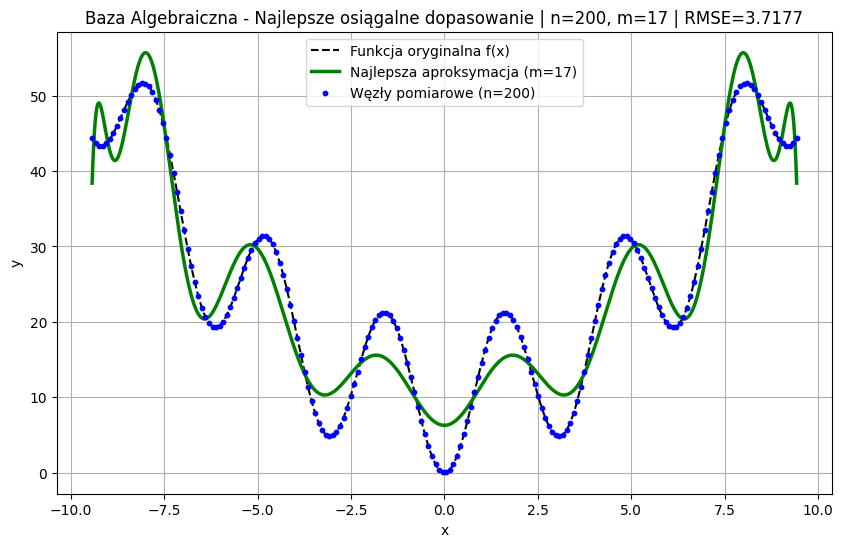

Zapisano wykres optymalny: ./plots/algebraic/exp_n200_m17_optymalny.png


In [10]:
# --- Poszukiwanie optymalnego 'm' dla bazy algebraicznej ---
print("Szukam optymalnego stopnia 'm' dla bazy algebraicznej (n=200)...")

best_m = 2
min_rmse = float('inf')
best_coeffs = None

n_opt = 200
x_nodes_opt = np.linspace(a, b, n_opt)
y_nodes_opt = f(x_nodes_opt)

x_dense_opt = np.linspace(a, b, 1000)
y_true_dense_opt = f(x_dense_opt)

# Przeszukujemy sensowny zakres stopni wielomianu
for m in range(2, 18):
    basis = get_algebraic_basis(m)
    try:
        coeffs = solve_approximation(x_nodes_opt, y_nodes_opt, basis)
        y_approx = evaluate_model(x_dense_opt, coeffs, basis)
        rmse = np.sqrt(calculate_mse(y_true_dense_opt, y_approx))
        
        # Zapisujemy najlepszy wynik
        if rmse < min_rmse:
            min_rmse = rmse
            best_m = m
            best_coeffs = coeffs
    except np.linalg.LinAlgError:
        continue # Ignorujemy stopnie, które wysadzają układ

print(f"ZNALEZIONO! Najlepsze dopasowanie osiągnięto przy m = {best_m} (RMSE = {min_rmse:.4f})")

# --- Rysowanie najlepszego wariantu ---
best_basis = get_algebraic_basis(best_m)
y_best_approx = evaluate_model(x_dense_opt, best_coeffs, best_basis)

plt.figure(figsize=(10, 6))
plt.plot(x_dense_opt, y_true_dense_opt, 'k--', label='Funkcja oryginalna f(x)')
plt.plot(x_dense_opt, y_best_approx, 'g-', linewidth=2.5, label=f'Najlepsza aproksymacja (m={best_m})')
plt.scatter(x_nodes_opt, y_nodes_opt, color='blue', s=10, zorder=5, label=f'Węzły pomiarowe (n={n_opt})')

plt.title(f'Baza Algebraiczna - Najlepsze osiągalne dopasowanie | n={n_opt}, m={best_m} | RMSE={min_rmse:.4f}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

opt_plot_path = f"./plots/algebraic/exp_n{n_opt}_m{best_m}_optymalny.png"
plt.savefig(opt_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Zapisano wykres optymalny: {opt_plot_path}")

## Krok 5: Generowanie *heatmap*
Generowanie heatmap w zależności od $m$ i $n$ dla obu baz.

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

# 1. Lekka funkcja tylko do obliczania błędu RMSE
def get_rmse_for_heatmap(n, m, basis_type):
    x_nodes = np.linspace(a, b, n)
    y_nodes = f(x_nodes)
    
    x_dense = np.linspace(a, b, 1000)
    y_true_dense = f(x_dense)
    
    if basis_type == 'algebraic':
        basis = get_algebraic_basis(m)
    elif basis_type == 'trigonometric':
        basis = get_trig_basis(m)
        
    try:
        coeffs = solve_approximation(x_nodes, y_nodes, basis)
        y_approx_dense = evaluate_model(x_dense, coeffs, basis)
        rmse = np.sqrt(calculate_mse(y_true_dense, y_approx_dense))
        return rmse
    except np.linalg.LinAlgError:
        return np.nan 

# 2. Gęstsza siatka eksperymentalna
n_values = [10, 15, 20, 30, 50, 75, 100, 150, 200, 300, 500]
m_alg_values = [2, 4, 6, 8, 10, 12, 14, 16, 20, 25]
m_trig_values = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15]

# 3. Generowanie danych dla macierzy
def create_heatmap_data(n_vals, m_vals, basis_type):
    results = np.zeros((len(m_vals), len(n_vals)))
    y_labels = []
    
    for i, m in enumerate(m_vals):
        if basis_type == 'algebraic':
            num_basis = m + 1
        else:
            num_basis = 2 * m + 1
            
        y_labels.append(f"m={m} (funkcji: {num_basis})")
        
        for j, n in enumerate(n_vals):
            results[i, j] = get_rmse_for_heatmap(n, m, basis_type)
            
    return results, y_labels

print("Liczenie danych dla heatmapy algebraicznej...")
rmse_alg, y_labels_alg = create_heatmap_data(n_values, m_alg_values, 'algebraic')

print("Liczenie danych dla heatmapy trygonometrycznej...")
rmse_trig, y_labels_trig = create_heatmap_data(n_values, m_trig_values, 'trigonometric')

# 4. Rysowanie i zapisywanie osobnych Heatmap

# --- Heatmapa Algebraiczna ---
plt.figure(figsize=(10, 8))
sns.heatmap(rmse_alg, xticklabels=n_values, yticklabels=y_labels_alg, 
            annot=True, fmt=".1f", cmap="YlOrRd", 
            norm=LogNorm(vmin=np.nanmin(rmse_alg[rmse_alg>0]), vmax=np.nanmax(rmse_alg)))
plt.title('Błąd RMSE - Baza Algebraiczna')
plt.xlabel('Liczba punktów pomiarowych (n)')
plt.ylabel('Stopień m (oraz liczba funkcji bazowych)')
plt.tight_layout()
path_alg = "./plots/algebraic/heatmap_rmse.png"
plt.savefig(path_alg, dpi=300)
plt.close()
print(f"Zapisano: {path_alg}")

# --- Heatmapa Trygonometryczna ---
plt.figure(figsize=(10, 8))
sns.heatmap(rmse_trig, xticklabels=n_values, yticklabels=y_labels_trig, 
            annot=True, fmt=".1f", cmap="YlOrRd", 
            norm=LogNorm(vmin=np.nanmin(rmse_trig[rmse_trig>0]), vmax=np.nanmax(rmse_trig)))
plt.title('Błąd RMSE - Baza Trygonometryczna')
plt.xlabel('Liczba punktów pomiarowych (n)')
plt.ylabel('Stopień m (oraz liczba funkcji bazowych)')
plt.tight_layout()
path_trig = "./plots/trigonometric/heatmap_rmse.png"
plt.savefig(path_trig, dpi=300)
plt.close()
print(f"Zapisano: {path_trig}")

Liczenie danych dla heatmapy algebraicznej...
Liczenie danych dla heatmapy trygonometrycznej...
Zapisano: ./plots/algebraic/heatmap_rmse.png
Zapisano: ./plots/trigonometric/heatmap_rmse.png
